# 03 — Analyse NER du corpus politique avec spaCy

## Objectif

Après la partie **classification** (Bag-of-Words, TF-IDF, modèles linéaires, LSTM et GRU), ce notebook ajoute une **analyse linguistique complémentaire** fondée sur la **reconnaissance d’entités nommées (NER)**.

L’objectif n’est plus seulement de prédire `left` ou `right`, mais de répondre à des questions comme :

- quels types d’entités nommées apparaissent dans les professions de foi ?
- la gauche et la droite citent-elles les mêmes catégories d’entités ?
- quels noms de personnes, de lieux, d’organisations ou d’institutions reviennent le plus souvent ?
- peut-on enrichir l’interprétation politique du corpus grâce à ces entités ?

## Démarche

Dans ce notebook, nous suivons la logique suivante :

1. charger le corpus final ;
2. appliquer un modèle **spaCy** pré-entraîné en français ;
3. extraire les entités nommées document par document ;
4. produire des statistiques globales et par orientation politique ;
5. visualiser les résultats ;
6. interpréter ce que les entités révèlent sur le discours politique.


## 0. Dépendances

Ce notebook repose principalement sur :

- `pandas`
- `matplotlib`
- `seaborn`
- `spacy`


In [1]:
%pip install pandas matplotlib seaborn spacy
%python -m spacy download fr_core_news_md

  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached markdown_it_py-4.0.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.8/32.8 MB 47.5 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 839.9/839.9 kB 42.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 41.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 66.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 68.5 MB/s  0:00:00
Using cached rich-15.0.0-py3-none-any.whl (310 kB)
Using cached markdown_it_py-4.0.0-py3-none-any.whl (87 kB)
Using cached mdurl-0.1.2-py3-none-any.whl (10.0 kB)
Using cached shellingham-1.5.4-py2.py3-none-any.whl (9.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20/20 [spacy]m19/20 [spacy]]ion]
Note: you may need to restart the kernel to

UsageError: Line magic function `%python` not found (But cell magic `%%python` exists, did you mean that instead?).


## 1. Imports et configuration

Nous importons ici les bibliothèques nécessaires à la manipulation des données, aux visualisations et à l’inférence NER avec spaCy.


In [ ]:
from pathlib import Path
from collections import Counter, defaultdict

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import spacy
from tqdm.auto import tqdm

pd.set_option("display.max_colwidth", 200)
tqdm.pandas()

## 2. Chargement du corpus

Nous chargeons le jeu de données final produit dans les étapes précédentes.  
Chaque ligne correspond à une profession de foi et contient au minimum :

- `text` : le texte du document ;
- `label` : l’orientation politique (`left` ou `right`).

Adapte le chemin si nécessaire.


In [ ]:
DATA_PATH = Path("dataset_1993_final_clean.csv")
assert DATA_PATH.exists(), f"Fichier introuvable : {DATA_PATH}"

df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(2523, 3)


,id,text,label
0,EL189_L_1993_03_001_01_1_PF_01,"elections legislatives de mars 93 front national les français d'abord ! bernard aulagne 49 ans, marié, 3 enfants, artisan graveur ornemaniste croix de la valeur militaire suppleant : jacky saude 5...",right
1,EL189_L_1993_03_001_01_1_PF_02,sciences po / fonds cevipof république française - élections législatives - 21 mars 1993 - département de l'ain - 1e circonscription lionel mornet ouvrier rvi - conseiller municipal bourg-en-bress...,left
2,EL189_L_1993_03_001_01_1_PF_03,sciences po / fonds cevipof elections législatives de mars 1993 - 1re circonscription de l'ain jacques boyon ancien ministre député-maire de pont-d'ain chevalier de la légion d'honneur père de 7 e...,right
3,EL189_L_1993_03_001_01_1_PF_04,elections législatives du 21 mars 1993 pourquoi voter lutte ouvrière un appel d'arlette laguiller en faveur du candidat de lutte ouvrière de votre circonscription le chômage n'est pas un phénomène...,left
4,EL189_L_1993_03_001_01_1_PF_06,sciences po / fonds cevipof elections legislatives du 21 mars 1993 - 1ere circonscription de l'ain jean-françois mortel jean-françois mortel a trente-neuf ans. il est éducateur dans un centre d'hé...,left


## 3. Vérifications de base

Avant l’analyse NER, nous vérifions :

- la présence de valeurs manquantes ;
- la distribution des classes ;
- la longueur approximative des textes.

Ces informations permettent d’estimer la taille du traitement à venir.


In [ ]:
print(df.columns.tolist())
print()
print(df.isna().sum())
print()
print(df["label"].value_counts(dropna=False))
print()
df["word_count"] = df["text"].astype(str).str.split().str.len()
df["word_count"].describe()

['id', 'text', 'label']

id       0
text     0
label    0
dtype: int64

label
right    1351
left     1172
Name: count, dtype: int64



,word_count
count,2523.000000
mean,770.743956
std,307.105131
min,47.000000
25%,536.000000
50%,783.000000
75%,925.000000
max,2651.000000


## 4. Chargement du modèle spaCy français

Nous utilisons un modèle pré-entraîné en français.  
Le plus adapté ici est `fr_core_news_md` si disponible, sinon `fr_core_news_sm`.

Le modèle détectera automatiquement des entités comme :

- **PER** : personnes
- **LOC** : lieux
- **ORG** : organisations
- **MISC** : autres entités nommées

La liste exacte dépend du modèle chargé.


In [ ]:
MODEL_CANDIDATES = ["fr_core_news_md", "fr_core_news_sm"]

nlp = None
loaded_model_name = None

for model_name in MODEL_CANDIDATES:
    try:
        nlp = spacy.load(model_name)
        loaded_model_name = model_name
        break
    except OSError:
        continue

if nlp is None:
    raise OSError(
        "Aucun modèle spaCy français n'est disponible. "
        "Installe par exemple : python -m spacy download fr_core_news_md"
    )

loaded_model_name

'fr_core_news_md'

## 5. Prétraitement léger avant NER

Nous appliquons un nettoyage minimal :

- suppression des retours à la ligne ;
- normalisation des espaces.

L’objectif n’est pas de modifier le contenu, mais de faciliter le passage dans le pipeline spaCy.


In [ ]:
def normalize_text(text: str) -> str:
    text = str(text)
    text = text.replace("\n", " ").replace("\r", " ")
    text = " ".join(text.split())
    return text.strip()

df["text_ner"] = df["text"].apply(normalize_text)
df[["text", "text_ner"]].head(2)

,text,text_ner
0,"elections legislatives de mars 93 front national les français d'abord ! bernard aulagne 49 ans, marié, 3 enfants, artisan graveur ornemaniste croix de la valeur militaire suppleant : jacky saude 5...","elections legislatives de mars 93 front national les français d'abord ! bernard aulagne 49 ans, marié, 3 enfants, artisan graveur ornemaniste croix de la valeur militaire suppleant : jacky saude 5..."
1,sciences po / fonds cevipof république française - élections législatives - 21 mars 1993 - département de l'ain - 1e circonscription lionel mornet ouvrier rvi - conseiller municipal bourg-en-bress...,sciences po / fonds cevipof république française - élections législatives - 21 mars 1993 - département de l'ain - 1e circonscription lionel mornet ouvrier rvi - conseiller municipal bourg-en-bress...


## 6. Extraction des entités nommées

Nous appliquons le modèle spaCy à l’ensemble du corpus avec `nlp.pipe`, ce qui est plus efficace qu’un traitement document par document.

Pour chaque document, nous stockons :

- la liste des entités détectées ;
- leur texte ;
- leur label NER ;
- leur position éventuelle dans le document.


In [ ]:
def extract_ents(doc):
    return [
        {
            "text": ent.text,
            "label": ent.label_,
            "start": ent.start_char,
            "end": ent.end_char,
        }
        for ent in doc.ents
    ]

docs = list(tqdm(nlp.pipe(df["text_ner"].tolist(), batch_size=32), total=len(df)))
df["entities"] = [extract_ents(doc) for doc in docs]
df["n_entities"] = df["entities"].apply(len)

print("Nombre moyen d'entités par document :", round(df["n_entities"].mean(), 2))
df[["label", "n_entities"]].head()

  0%|          | 0/2523 [00:00<?, ?it/s]

Nombre moyen d'entités par document : 24.68


,label,n_entities
0,right,19
1,left,39
2,right,23
3,left,6
4,left,23


Le modèle détecte en moyenne **24,68 entités par document**, ce qui est très élevé. Ce résultat suggère que les professions de foi sont fortement structurées par des références à des acteurs, des lieux, des organisations et des institutions.

## 7. Contrôle rapide sur quelques exemples

Cette étape permet de vérifier qualitativement ce que le modèle extrait réellement.


In [ ]:
for idx in [0, 1, 2]:
    print("=" * 100)
    print("LABEL :", df.iloc[idx]["label"])
    print("TEXTE :", df.iloc[idx]["text_ner"][:600], "...")
    print("ENTITÉS :", df.iloc[idx]["entities"][:10])

LABEL : right
TEXTE : elections legislatives de mars 93 front national les français d'abord ! bernard aulagne 49 ans, marié, 3 enfants, artisan graveur ornemaniste croix de la valeur militaire suppleant : jacky saude 52 ans, retraité de la gendarmerie président des anciens gendarmes de lagnieu sciences po / fonds cevipof mes chers compatriotes, chômage, insécurité, immigration, pauvreté, impôts, "affaires" ... force est de constater qu'en france aujourd'hui rien ne va plus ! ce cons- tat dramatique, mais malheureusement bien réel, vous inquiète. or, il y a des responsables à cet état de fait : ce sont les politicie ...
ENTITÉS : [{'text': 'front national les français', 'label': 'ORG', 'start': 34, 'end': 61}, {'text': 'bernard', 'label': 'MISC', 'start': 72, 'end': 79}, {'text': 'jacky', 'label': 'PER', 'start': 183, 'end': 188}, {'text': 'lagnieu', 'label': 'LOC', 'start': 265, 'end': 272}, {'text': 'france', 'label': 'LOC', 'start': 421, 'end': 427}, {'text': 'la france', 'label': 'L

## 8. Mise à plat des entités

Pour faciliter les statistiques, nous transformons les listes d’entités en une table à plat où chaque ligne correspond à une entité détectée.


In [ ]:
rows = []
for _, row in df.iterrows():
    doc_id = row.get("id", None)
    label = row["label"]
    for ent in row["entities"]:
        rows.append({
            "id": doc_id,
            "doc_label": label,
            "entity_text": ent["text"],
            "entity_label": ent["label"],
            "start": ent["start"],
            "end": ent["end"],
        })

entities_df = pd.DataFrame(rows)
print(entities_df.shape)
entities_df.head()

(62260, 6)


,id,doc_label,entity_text,entity_label,start,end
0,EL189_L_1993_03_001_01_1_PF_01,right,front national les français,ORG,34,61
1,EL189_L_1993_03_001_01_1_PF_01,right,bernard,MISC,72,79
2,EL189_L_1993_03_001_01_1_PF_01,right,jacky,PER,183,188
3,EL189_L_1993_03_001_01_1_PF_01,right,lagnieu,LOC,265,272
4,EL189_L_1993_03_001_01_1_PF_01,right,france,LOC,421,427


La mise à plat des entités produit un tableau de **62 260 occurrences**, ce qui permet une analyse quantitative détaillée du corpus. Cette structure est particulièrement utile pour comparer les orientations politiques, mesurer la fréquence des types d’entités et identifier les références les plus récurrentes.

Le volume obtenu confirme à la fois la richesse du corpus en références nommées et le caractère potentiellement bruité de l’extraction, ce qui justifie une lecture à la fois statistique et qualitative.

## 9. Statistiques générales sur les entités

Nous cherchons ici à répondre à plusieurs questions :

- combien de documents contiennent au moins une entité ?
- quels sont les labels NER les plus fréquents ?
- quelles entités reviennent le plus souvent ?


In [ ]:
docs_with_entities = (df["n_entities"] > 0).sum()
print("Documents avec au moins une entité :", docs_with_entities)
print("Proportion :", round(docs_with_entities / len(df), 4))

print("\nRépartition globale des labels NER :")
if not entities_df.empty:
    print(entities_df["entity_label"].value_counts())
else:
    print("Aucune entité détectée.")

Documents avec au moins une entité : 2523
Proportion : 1.0

Répartition globale des labels NER :
entity_label
LOC     23382
PER     18609
ORG     14797
MISC     5472
Name: count, dtype: int64


Tous les documents contiennent au moins une entité nommée détectée, ce qui montre que l’information nominative est omniprésente dans le corpus. La catégorie la plus fréquente est **LOC** (**23 382 occurrences**), suivie de **PER** (**18 609**) et **ORG** (**14 797**).

Cette hiérarchie est intéressante : les professions de foi semblent mobiliser très fortement des références spatiales et institutionnelles, en plus des personnes et des partis. Cela suggère que le discours politique s’ancre à la fois dans des territoires, des acteurs et des organisations.

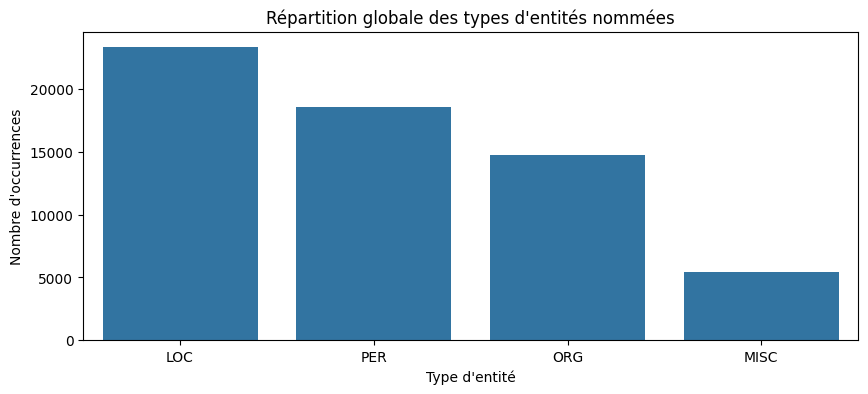

In [ ]:
if not entities_df.empty:
    plt.figure(figsize=(10, 4))
    sns.countplot(data=entities_df, x="entity_label", order=entities_df["entity_label"].value_counts().index)
    plt.title("Répartition globale des types d'entités nommées")
    plt.xlabel("Type d'entité")
    plt.ylabel("Nombre d'occurrences")
    plt.show()

## 10. Entités les plus fréquentes dans tout le corpus

Cette étape permet de voir quels noms propres dominent globalement le corpus.


In [ ]:
if not entities_df.empty:
    top_entities_global = (
        entities_df["entity_text"]
        .str.strip()
        .value_counts()
        .head(30)
        .reset_index()
    )
    top_entities_global.columns = ["entity_text", "count"]
    top_entities_global
else:
    print("Aucune entité détectée.")

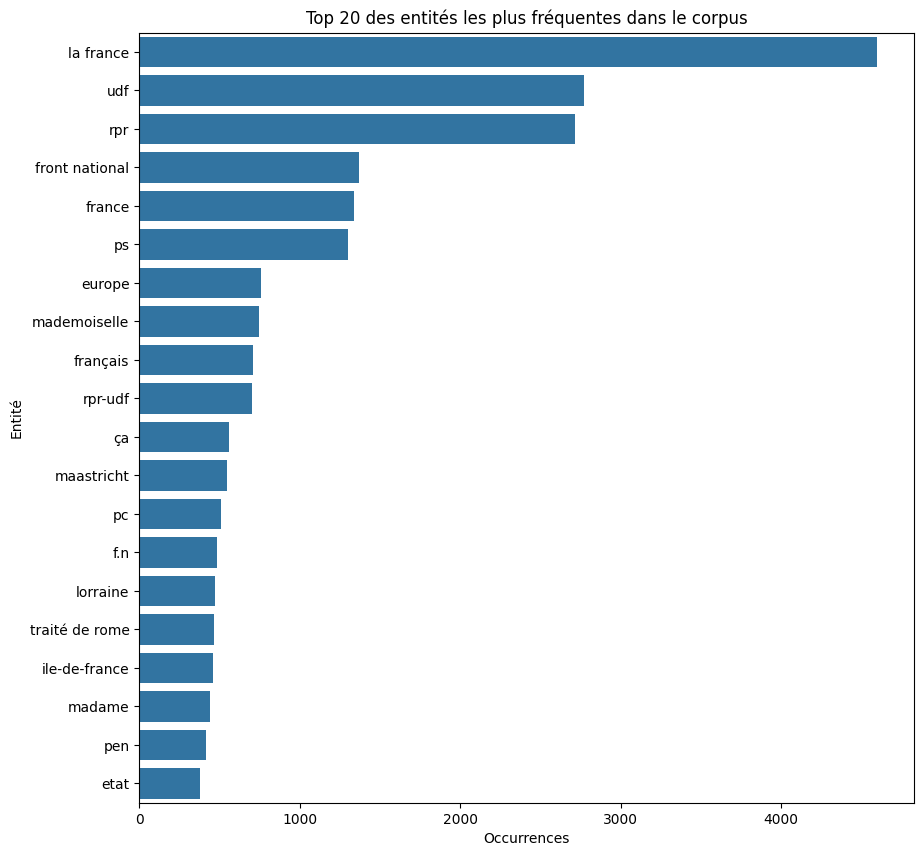

In [ ]:
if not entities_df.empty:
    plt.figure(figsize=(10, 10))
    sns.barplot(data=top_entities_global.head(20), y="entity_text", x="count")
    plt.title("Top 20 des entités les plus fréquentes dans le corpus")
    plt.xlabel("Occurrences")
    plt.ylabel("Entité")
    plt.show()

Les entités les plus fréquentes montrent que le corpus est fortement structuré par des références politiques explicites : partis, personnalités, espaces nationaux ou européens. Cela confirme que les professions de foi ne sont pas seulement des textes argumentatifs abstraits ; elles s’inscrivent dans un univers concret d’acteurs, d’organisations et de lieux.

Cependant, certaines formes récurrentes doivent être interprétées avec prudence. Dans ce type de corpus, une entité fréquente n’est pas toujours synonyme de pertinence politique maximale : elle peut aussi résulter d’une répétition documentaire, d’un effet de formule, ou d’une reconnaissance imparfaite du modèle.

## 11. Comparaison gauche / droite : quantité d’entités

Nous comparons ici le nombre moyen d’entités détectées selon l’orientation politique.


In [ ]:
df.groupby("label")["n_entities"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
left,1172.0,19.450512,13.158630,4.0,12.0,18.0,23.0,163.0
right,1351.0,29.210955,20.592247,1.0,17.0,27.0,37.0,228.0


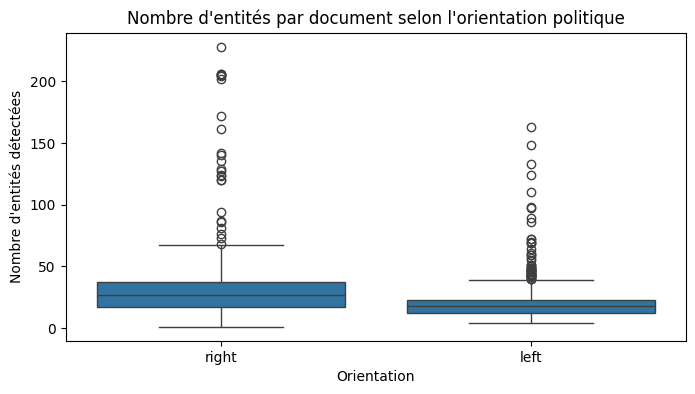

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="label", y="n_entities")
plt.title("Nombre d'entités par document selon l'orientation politique")
plt.xlabel("Orientation")
plt.ylabel("Nombre d'entités détectées")
plt.show()

## 12. Répartition des types d’entités selon la classe politique

Nous cherchons maintenant à savoir si la gauche et la droite citent les mêmes types d’entités :
- davantage de personnes ?
- davantage d’organisations ?
- davantage de lieux ?


In [ ]:
if not entities_df.empty:
    ner_by_class = (
        entities_df.groupby(["doc_label", "entity_label"])
        .size()
        .reset_index(name="count")
    )
    ner_by_class
else:
    print("Aucune entité détectée.")

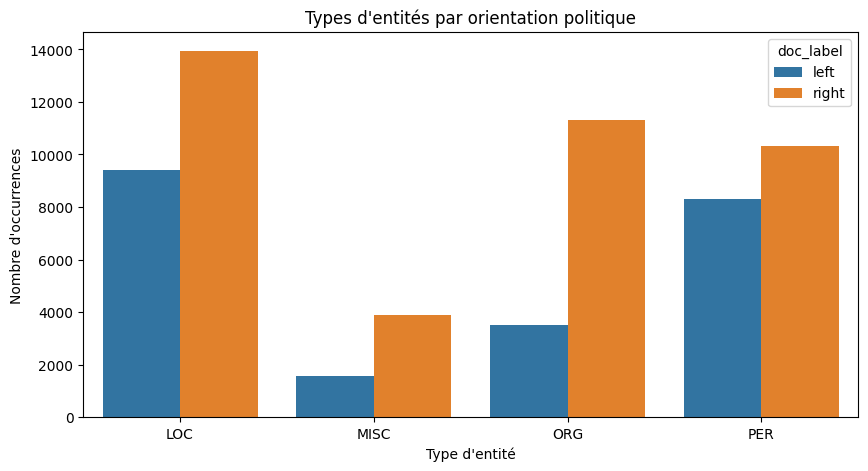

In [ ]:
if not entities_df.empty:
    plt.figure(figsize=(10, 5))
    sns.barplot(data=ner_by_class, x="entity_label", y="count", hue="doc_label")
    plt.title("Types d'entités par orientation politique")
    plt.xlabel("Type d'entité")
    plt.ylabel("Nombre d'occurrences")
    plt.show()

La comparaison des types d’entités selon l’orientation politique montre que la différence entre gauche et droite ne porte pas seulement sur le nombre total d’entités, mais aussi sur leur nature. Les deux camps n’activent pas nécessairement les mêmes univers référentiels.

Cette observation enrichit l’analyse politique du corpus : elle suggère que les oppositions discursives entre gauche et droite passent aussi par des choix différents de personnes, d’organisations, de lieux et d’institutions mentionnés.

## 13. Top entités par classe

Nous extrayons maintenant les entités les plus fréquentes séparément pour `left` et `right`.


In [ ]:
def top_entities_by_label(label_value, top_n=20):
    sub = entities_df[entities_df["doc_label"] == label_value].copy()
    if sub.empty:
        return pd.DataFrame(columns=["entity_text", "count"])
    out = (
        sub["entity_text"]
        .str.strip()
        .value_counts()
        .head(top_n)
        .reset_index()
    )
    out.columns = ["entity_text", "count"]
    return out

top_left_entities = top_entities_by_label("left", top_n=20)
top_right_entities = top_entities_by_label("right", top_n=20)

print("=== LEFT ===")
display(top_left_entities)

print("=== RIGHT ===")
display(top_right_entities)

=== LEFT ===


,entity_text,count
0,la france,991
1,mademoiselle,491
2,maastricht,483
3,europe,476
4,france,402
5,ps,326
6,madame,305
7,pcf,292
8,michel rocard,289
9,l'europe,227


=== RIGHT ===


,entity_text,count
0,la france,3607
1,udf,2656
2,rpr,2604
3,front national,1305
4,ps,978
5,france,936
6,rpr-udf,617
7,français,603
8,pc,492
9,f.n,478


Les entités dominantes diffèrent nettement entre les deux classes. Du côté gauche, on observe davantage de références à des enjeux européens et à certaines figures ou organisations associées à cet espace politique, comme **Maastricht**, **Europe**, **Michel Rocard**, **PS** ou **PCF**. Du côté droit, les références semblent plus fortement liées aux alliances partisanes et à l’espace politique national, avec des entités comme **UDF**, **RPR** ou **Front national**.

Ce contraste est très informatif : il confirme que la NER ne fait pas que repérer des noms propres, elle met aussi en évidence des **univers politiques distincts**.

En revanche, la présence d’entités comme **mademoiselle** ou **madame** dans les sorties les plus fréquentes révèle également un bruit non négligeable. Cela montre que le modèle capte à la fois un signal politique réel et des artefacts liés à l’OCR ou à la généralité du modèle pré-entraîné.

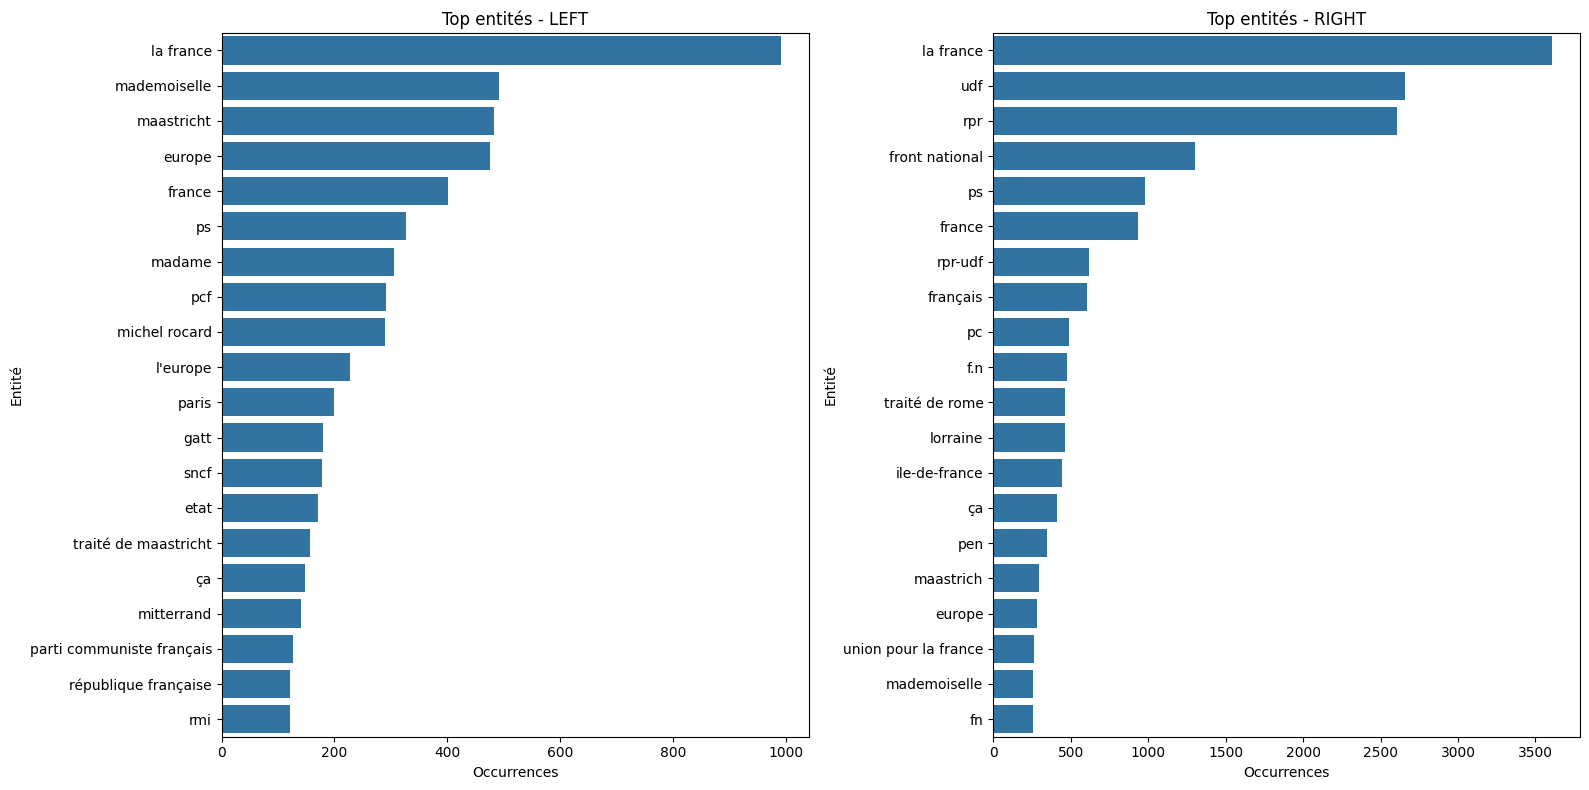

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

if not top_left_entities.empty:
    sns.barplot(data=top_left_entities, y="entity_text", x="count", ax=axes[0])
    axes[0].set_title("Top entités - LEFT")
    axes[0].set_xlabel("Occurrences")
    axes[0].set_ylabel("Entité")

if not top_right_entities.empty:
    sns.barplot(data=top_right_entities, y="entity_text", x="count", ax=axes[1])
    axes[1].set_title("Top entités - RIGHT")
    axes[1].set_xlabel("Occurrences")
    axes[1].set_ylabel("Entité")

plt.tight_layout()
plt.show()

## 14. Focus par type d’entité

Il est souvent plus intéressant de séparer l’analyse selon les types d’entités.  
Par exemple : uniquement les personnes, uniquement les organisations, etc.


In [ ]:
def top_entities_for_type(entity_type, top_n=15):
    sub = entities_df[entities_df["entity_label"] == entity_type].copy()
    if sub.empty:
        return pd.DataFrame(columns=["entity_text", "count"])
    out = (
        sub["entity_text"]
        .str.strip()
        .value_counts()
        .head(top_n)
        .reset_index()
    )
    out.columns = ["entity_text", "count"]
    return out

if not entities_df.empty:
    available_entity_types = entities_df["entity_label"].value_counts().index.tolist()
    print("Types disponibles :", available_entity_types)
else:
    available_entity_types = []

Types disponibles : ['LOC', 'PER', 'ORG', 'MISC']


In [ ]:
ENTITY_TYPE_TO_INSPECT = available_entity_types[0] if len(available_entity_types) > 0 else None

if ENTITY_TYPE_TO_INSPECT is not None:
    top_type_entities = top_entities_for_type(ENTITY_TYPE_TO_INSPECT, top_n=20)
    print(f"Top entités pour le type {ENTITY_TYPE_TO_INSPECT}")
    display(top_type_entities)
else:
    print("Aucun type d'entité disponible.")

Top entités pour le type LOC


,entity_text,count
0,la france,4598
1,france,1338
2,europe,718
3,maastricht,550
4,mademoiselle,482
5,lorraine,473
6,ile-de-france,460
7,f.n,445
8,etat,381
9,paris,375


L’analyse des entités de type `LOC` est particulièrement révélatrice. Elle confirme la forte présence de références géographiques et politiques comme **la France**, **l’Europe**, **Maastricht**, **Paris** ou **l’Île-de-France**. Ces entités traduisent l’ancrage territorial du discours électoral.

Mais cette analyse met aussi en évidence les limites du modèle : certaines formes comme **mademoiselle**, **f.n** ou **etat** apparaissent ici comme des lieux alors qu’elles relèvent manifestement d’erreurs de catégorisation ou de bruit OCR.  

Cette étape montre donc bien le double visage du NER sur ce corpus :  
- une vraie capacité à repérer les grands référents du discours politique ;  
- mais aussi une sensibilité importante aux imperfections textuelles.

## 15. Exemples qualitatifs

Nous affichons quelques documents contenant plusieurs entités afin d’interpréter qualitativement les sorties du modèle.


In [ ]:
examples = df[df["n_entities"] >= 3][["label", "text_ner", "entities"]].head(5)
examples

,label,text_ner,entities
0,right,"elections legislatives de mars 93 front national les français d'abord ! bernard aulagne 49 ans, marié, 3 enfants, artisan graveur ornemaniste croix de la valeur militaire suppleant : jacky saude 5...","[{'text': 'front national les français', 'label': 'ORG', 'start': 34, 'end': 61}, {'text': 'bernard', 'label': 'MISC', 'start': 72, 'end': 79}, {'text': 'jacky', 'label': 'PER', 'start': 183, 'end..."
1,left,sciences po / fonds cevipof république française - élections législatives - 21 mars 1993 - département de l'ain - 1e circonscription lionel mornet ouvrier rvi - conseiller municipal bourg-en-bress...,"[{'text': 'département de l'ain', 'label': 'LOC', 'start': 91, 'end': 111}, {'text': 'lionel mornet ouvrier rvi', 'label': 'PER', 'start': 133, 'end': 158}, {'text': 'bourg-en-bresse', 'label': 'L..."
2,right,sciences po / fonds cevipof elections législatives de mars 1993 - 1re circonscription de l'ain jacques boyon ancien ministre député-maire de pont-d'ain chevalier de la légion d'honneur père de 7 e...,"[{'text': 'jacques boyon', 'label': 'PER', 'start': 95, 'end': 108}, {'text': 'paul morin', 'label': 'PER', 'start': 215, 'end': 225}, {'text': 'bresse', 'label': 'LOC', 'start': 244, 'end': 250},..."
3,left,elections législatives du 21 mars 1993 pourquoi voter lutte ouvrière un appel d'arlette laguiller en faveur du candidat de lutte ouvrière de votre circonscription le chômage n'est pas un phénomène...,"[{'text': 'arlette laguiller', 'label': 'PER', 'start': 80, 'end': 97}, {'text': 'france', 'label': 'LOC', 'start': 2386, 'end': 2392}, {'text': 'etat', 'label': 'LOC', 'start': 2682, 'end': 2686}..."
4,left,sciences po / fonds cevipof elections legislatives du 21 mars 1993 - 1ere circonscription de l'ain jean-françois mortel jean-françois mortel a trente-neuf ans. il est éducateur dans un centre d'hé...,"[{'text': 'jean-françois mortel', 'label': 'PER', 'start': 99, 'end': 119}, {'text': 'jean-françois mortel', 'label': 'PER', 'start': 120, 'end': 140}, {'text': 'bourg-en-bresse', 'label': 'LOC', ..."


## 16. Sauvegarde des résultats

Nous sauvegardons :

- la table complète des entités extraites ;
- un fichier enrichi document par document avec le nombre d’entités.


In [24]:
OUTPUT_DIR = Path("outputs/ner_analysis")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df[["label", "text_ner", "n_entities", "entities"]].to_csv(OUTPUT_DIR / "documents_with_entities.csv", index=False)
entities_df.to_csv(OUTPUT_DIR / "entities_flat.csv", index=False)

print("Fichiers sauvegardés dans :", OUTPUT_DIR.resolve())

Fichiers sauvegardés dans : /content/outputs/ner_analysis


## 17. Discussion

L’analyse NER confirme que les professions de foi sont fortement structurées par des références explicites à des personnes, des organisations, des partis et des lieux. Cette dimension nominative complète utilement les résultats obtenus dans la partie classification : alors que la classification mettait en évidence des différences lexicales et idéologiques, la NER montre que ces différences s’inscrivent aussi dans des univers d’acteurs et de références distincts.

Les résultats indiquent en particulier que les documents classés à droite contiennent en moyenne davantage d’entités nommées que ceux classés à gauche (**29,21** contre **19,45**). Cette différence suggère une mobilisation plus dense d’alliances, de formations politiques, de références nationales ou institutionnelles dans les textes de droite.

Par ailleurs, l’analyse des entités les plus fréquentes montre un contraste clair entre les deux camps. Les textes de gauche font davantage apparaître des références comme **Europe**, **Maastricht**, **Michel Rocard**, **PS** ou **PCF**, tandis que les textes de droite mobilisent plus souvent des entités telles que **UDF**, **RPR** ou **Front national**. Cela confirme que les deux orientations politiques ne se distinguent pas seulement par leur vocabulaire idéologique, mais aussi par les acteurs et les espaces qu’elles mettent en scène.

Toutefois, cette analyse doit être nuancée par des limites méthodologiques importantes. Le modèle utilisé est un modèle NER pré-entraîné généraliste, non spécialisé sur des professions de foi OCRisées. De plus, les sorties montrent un bruit réel : certaines entités fréquentes comme **mademoiselle**, **madame**, **f.n** ou certaines formes mal reconnues reflètent les limites combinées du modèle et de l’OCR.

Ainsi, le NER fournit ici une lecture très utile du corpus, mais il doit être interprété comme un outil d’exploration et d’enrichissement analytique, et non comme une annotation parfaitement fiable.


## Conclusion

Cette étape NER enrichit réellement le projet. Elle montre que les professions de foi de gauche et de droite ne se distinguent pas seulement par leurs thèmes ou leurs mots-clés, mais aussi par les personnes, les organisations et les lieux qu’elles mobilisent.

Les résultats obtenus mettent en évidence un signal politique clair, en particulier dans les différences entre les entités dominantes des deux camps. En même temps, ils révèlent les limites d’un modèle pré-entraîné généraliste appliqué à un corpus OCRisé, où le bruit documentaire reste important.

La NER ne remplace donc pas la classification : elle la complète, en apportant une dimension linguistique et interprétative supplémentaire, très utile pour mieux comprendre la structure du discours politique.